# Meeting 10, Act 2: An Image Is an Array

**CS 301, Introduction to Data Science, NJIT.** Unit II, meeting 10.

A picture on a screen is also a block of numbers. In this act your group reads one picture as an array with two dimensions, then as an array with three, and computes new pictures from it.

## How this lab works

- **This is the notebook of Act 2 of meeting 10.** It starts from its own setup cell and uses nothing that was computed in the notebook of Act 1, except the number that your group drew there.
- **Work in the same group.** Each member opens this notebook and runs it. First open the **File** menu and choose **Save a copy in Drive**, so that your changes are kept.
- **Run the cells in order**, from the top. To run a cell, click it and press **Shift + Enter**.
- A paragraph that begins with **Your turn** asks you to do something before you go on.
- A code cell under the word **Check** tests your work and prints a message. If the message reports a problem, fix it before you go on.
- In Steps 13 and 15 you may ask an **AI assistant** to write code. Paste the prompt you used into the cell marked **Our prompt**, so that the notebook records how the code was made.
- **In Step 15** your group posts two pictures on the discussion board of this meeting. One member posts for the group, and every post begins with the names of all its members.
- **After the meeting**, **Review Quiz 10** on Canvas asks about this lab. Where the notebook says that the quiz asks about a point, read that part again before you take the quiz.

**Your turn.** Double-click this cell and replace this line with the names of the members of your group.

In [1]:
# Setup. Run this cell first.
import io
import time
from urllib.request import urlopen

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

# The address of the course's files for this unit, and of the folder that holds the images.
SITE = "https://ikoutis.github.io/cs301-labs/unit-2/"
IMAGES = SITE + "images/"


def read_image(file):
    """Read an image file into a NumPy array with values from 0 to 1."""
    return np.array(Image.open(urlopen(IMAGES + file))) / 255.0


def read_array(file):
    """Read an array of whole numbers from 0 to 255 from the course's files, as values from 0 to 1."""
    return np.load(io.BytesIO(urlopen(IMAGES + file).read())) / 255.0


def show(pictures, titles):
    """Draw arrays as pictures: an array with two dimensions in grey, one with three in colour."""
    columns = 2 if len(pictures) == 4 else len(pictures)
    lines = len(pictures) // columns
    fig, axes = plt.subplots(lines, columns, figsize=(5 * columns, 4.2 * lines), squeeze=False)
    for ax, picture, title in zip(axes.flat, pictures, titles):
        ax.imshow(np.clip(picture, 0, 1), cmap="gray", vmin=0, vmax=1)
        ax.set_title(title)
    fig.tight_layout()
    plt.show()


def average_time(function, data, repeats=5):
    """The average time of one call function(data), in seconds: the function of Step 9 in Act 1."""
    total = 0.0
    for _ in range(repeats):
        start = time.perf_counter()              # the clock before the call
        function(data)
        total += time.perf_counter() - start     # the time that this call took
    return total / repeats


print("Setup is done.")

Setup is done.


## <font color="#1967d2"><b>Step 11: A grey image is a matrix</b></font>

A digital image is a grid of small squares called **pixels**. In a **grey image** every pixel holds one number, its brightness: 0 is black, 1 is white, and the numbers between them are shades of grey. A grey image with H rows and W columns of pixels is therefore a **matrix** with H rows and W columns. In Act 1 a row of the matrix was one record; here a row is one horizontal line of pixels.

The course keeps thirty images, numbered like the datasets of Act 1. Your group's image has the number that your group drew in Act 1. If your group has no number, choose any number from 1 to 30.

**Your turn.** Every member types the group's number in the next cell, in place of the `0`, and runs the cell.

The cell reads the grey version of your image. The file stores each brightness as a whole number from 0 to 255; dividing by 255, which `read_image` does, brings it to the range from 0 to 1.

In [3]:
IMAGE = 20        # replace 0 with your group's number, from 1 to 30

assert 1 <= IMAGE <= 30, "Type your group's number in place of the 0."

images = pd.read_csv(IMAGES + "images.csv", index_col="number")
picture_info = images.loc[IMAGE]
print(f"Image {IMAGE}: {picture_info['title']} ({picture_info['creator']})")
print(f"Source: {picture_info['source']}")

grey = read_image(picture_info["grey_file"])
H, W = grey.shape
print(f"shape of grey: {grey.shape}, which is H = {H} rows and W = {W} columns of pixels, {H * W:,} numbers")
print(f"darkest value {grey.min():.2f}, brightest value {grey.max():.2f}, mean {grey.mean():.2f}")

Image 20: The Crab Nebula (Hubble) (NASA/ESA/JPL/Arizona State Univ.)
Source: https://images.nasa.gov/details/PIA03606
shape of grey: (640, 640), which is H = 640 rows and W = 640 columns of pixels, 409,600 numbers
darkest value 0.00, brightest value 1.00, mean 0.28


The next cell draws the array as a picture. Beside it, it draws a block of 12 by 12 pixels from the middle of the image, enlarged so that single pixels can be seen, and it prints the numbers of that block.

`grey[r:r + 12, c:c + 12]` selects a part of the matrix. `a:b` means the positions a, a + 1, and so on up to b − 1.

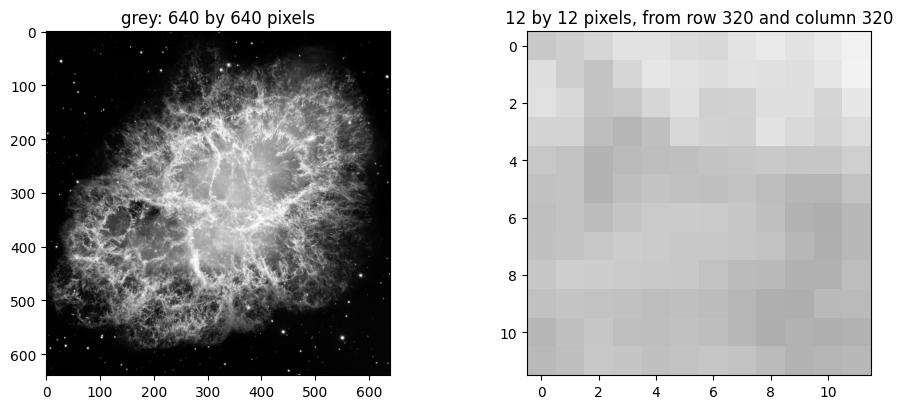

The numbers of the block, rounded to two decimals:
[[0.78 0.81 0.84 0.89 0.89 0.86 0.84 0.89 0.91 0.89 0.92 0.95]
 [0.87 0.81 0.77 0.84 0.9  0.88 0.87 0.88 0.88 0.87 0.9  0.95]
 [0.88 0.85 0.77 0.78 0.84 0.88 0.82 0.82 0.87 0.87 0.84 0.91]
 [0.83 0.83 0.74 0.71 0.75 0.84 0.82 0.82 0.89 0.85 0.83 0.86]
 [0.78 0.76 0.71 0.73 0.74 0.75 0.76 0.78 0.79 0.78 0.78 0.81]
 [0.76 0.76 0.71 0.75 0.77 0.76 0.75 0.76 0.74 0.71 0.71 0.76]
 [0.75 0.76 0.74 0.77 0.79 0.8  0.79 0.78 0.75 0.7  0.68 0.72]
 [0.75 0.76 0.78 0.8  0.79 0.78 0.78 0.78 0.77 0.72 0.69 0.72]
 [0.78 0.81 0.8  0.79 0.79 0.78 0.76 0.73 0.73 0.69 0.69 0.74]
 [0.76 0.77 0.76 0.76 0.74 0.75 0.74 0.72 0.69 0.68 0.73 0.73]
 [0.71 0.75 0.78 0.75 0.75 0.76 0.75 0.72 0.68 0.7  0.69 0.7 ]
 [0.73 0.75 0.78 0.77 0.75 0.77 0.78 0.76 0.73 0.7  0.71 0.72]]


In [4]:
r, c = H // 2, W // 2                    # the middle of the image
block = grey[r:r + 12, c:c + 12]         # 12 rows and 12 columns

show([grey, block], [f"grey: {H} by {W} pixels", f"12 by 12 pixels, from row {r} and column {c}"])
print("The numbers of the block, rounded to two decimals:")
print(np.round(block, 2))

**How to read the pictures.** The numbers along the edges are positions of rows and of columns. Row 0 is at the top, because a picture is drawn in the order in which the rows of the array are stored. In the enlarged block, each square is one pixel, and its shade is one number of the printed table: the larger the number, the lighter the square.

## <font color="#1967d2"><b>Step 12: A colour image is an array with three dimensions</b></font>

In a colour image every pixel holds **three** numbers: how much red, how much green and how much blue light it gives, each from 0 to 1. The image is an array with three dimensions, of shape H by W by 3:

- `image[i, j]` holds the three numbers of the pixel in row i and column j;
- `image[:, :, 0]` is the **red channel**: a matrix with H rows and W columns that holds the red number of every pixel. A colon alone means all positions along that dimension;
- `image[:, :, 1]` is the green channel, and `image[:, :, 2]` is the blue channel.

An array with any number of dimensions is also called a **tensor**. A matrix is a tensor with two dimensions.

shape of image: (640, 640, 3), which is 1,228,800 numbers
the pixel in row 0 and column 0: [0.02 0.   0.  ] (red, green, blue)
shape of one channel: (640, 640)
mean of each channel: red 0.28, green 0.29, blue 0.24


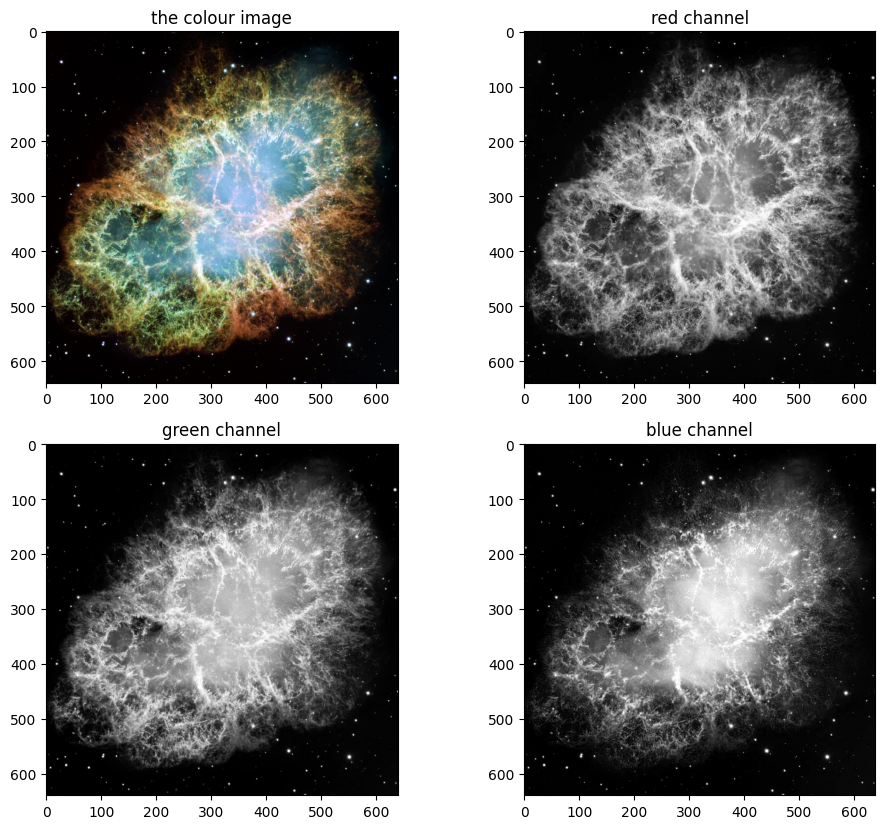

In [5]:
image = read_image(picture_info["file"])
print(f"shape of image: {image.shape}, which is {image.size:,} numbers")
print("the pixel in row 0 and column 0:", np.round(image[0, 0], 2), "(red, green, blue)")

red, green, blue = image[:, :, 0], image[:, :, 1], image[:, :, 2]
print("shape of one channel:", red.shape)
print(f"mean of each channel: red {red.mean():.2f}, green {green.mean():.2f}, blue {blue.mean():.2f}")

show([image, red, green, blue], ["the colour image", "red channel", "green channel", "blue channel"])

Each channel is a matrix, so it is drawn in grey: a pixel is light in the picture of the red channel where the image holds much red.

**Your turn.** Find a region of your image that is light in one channel and dark in another. What colour does that region have in the colour image? Answer in the next cell, in one sentence.

**Our answer.** Double-click this cell and replace this line with your answer.

## <font color="#1967d2"><b>Step 13: From colour to grey, in two ways</b></font>

A grey image can be computed from a colour image. A common rule gives every pixel the brightness

$$\text{grey} = 0.299 \cdot \text{red} + 0.587 \cdot \text{green} + 0.114 \cdot \text{blue}.$$

In words: 0.299 times the red number, plus 0.587 times the green number, plus 0.114 times the blue number. The three weights add to 1. Green has the largest weight because the eye is most sensitive to green light. The grey image of Step 11 was made from your colour image with this rule.

**Your turn.** Ask an AI assistant for **two** functions, in one prompt. Your prompt must state these requirements:

- `grey_loops(image)` uses two nested `for` loops, over the rows and over the columns. For each pixel it reads the three numbers `image[i, j, 0]`, `image[i, j, 1]` and `image[i, j, 2]`, and it stores the brightness in a new array created with `np.empty((H, W))`;
- `grey_vectorized(image)` computes the same result with no `for` loop, by arithmetic on whole channels;
- both take an array of shape (H, W, 3) and return an array of shape (H, W), with the three weights given above.

Paste your prompt into the next cell, and the two functions into the code cell after it.

**Our prompt.** Double-click this cell and replace this line with the prompt you gave to the AI assistant.

In [7]:
import numpy as np

def grey_loops(image):
    H, W, _ = image.shape
    grey = np.empty((H, W))
    for i in range(H):
        for j in range(W):
            grey[i, j] = 0.299 * image[i, j, 0] + 0.587 * image[i, j, 1] + 0.114 * image[i, j, 2]
    return grey

def grey_vectorized(image):
    return 0.299 * image[:, :, 0] + 0.587 * image[:, :, 1] + 0.114 * image[:, :, 2]

**Check.** The next cell compares both results with the grey image of Step 11. It then measures both functions with `average_time`, the function of Step 9 in Act 1, which the setup cell of this notebook defines again.

In [8]:
assert "grey_loops" in globals() and "grey_vectorized" in globals(), (
    "Paste the functions grey_loops and grey_vectorized into the cell above and run that cell.")

for function in (grey_loops, grey_vectorized):
    result = np.asarray(function(image), dtype=float)
    assert result.shape == (H, W), f"{function.__name__} returned an array of shape {result.shape}; it must be {(H, W)}."
    worst = np.abs(result - grey).max()
    assert worst < 0.005, (
        f"{function.__name__} differs from the grey image of Step 11 by up to {worst:.3f}. "
        "Check the three weights and the order of the channels.")
print("Correct: both functions reproduce the grey image of Step 11.")

t_grey_loops = average_time(grey_loops, image, 3)
t_grey_vectorized = average_time(grey_vectorized, image, 20)
print()
print(f"Image {IMAGE}: {H} by {W} pixels")
print(f"{'version':14s}{'seconds per call':>18s}{'nanoseconds per pixel':>24s}")
print(f"{'loops':14s}{t_grey_loops:18.4f}{t_grey_loops / (H * W) * 1e9:24.1f}")
print(f"{'vectorized':14s}{t_grey_vectorized:18.4f}{t_grey_vectorized / (H * W) * 1e9:24.1f}")
print(f"The loops take {t_grey_loops / t_grey_vectorized:.0f} times as long as the vectorized version.")

Correct: both functions reproduce the grey image of Step 11.

Image 20: 640 by 640 pixels
version         seconds per call   nanoseconds per pixel
loops                     0.4628                  1130.0
vectorized                0.0047                    11.4
The loops take 99 times as long as the vectorized version.


## <font color="#1967d2"><b>Step 14: One function applied to every entry</b></font>

In Act 1 the standard deviation needed the square of every distance from the mean, and the loop computed `d * d` for one entry at a time. On an array, `grey ** 2` squares **every** entry in one operation. An operation that applies the same function to each entry separately is called **pointwise**.

A pointwise operation on a grey image gives a new image of the same shape. Every brightness lies between 0 and 1, so:

- `grey ** 2` makes every value smaller, except 0 and 1, which stay as they are: the picture becomes darker;
- `np.sqrt(grey)` makes every value larger, except 0 and 1: the picture becomes lighter;
- `1 - grey` exchanges dark and light: the picture becomes its negative.

mean brightness: grey 0.28, grey ** 2 0.16, np.sqrt(grey) 0.43, 1 - grey 0.72


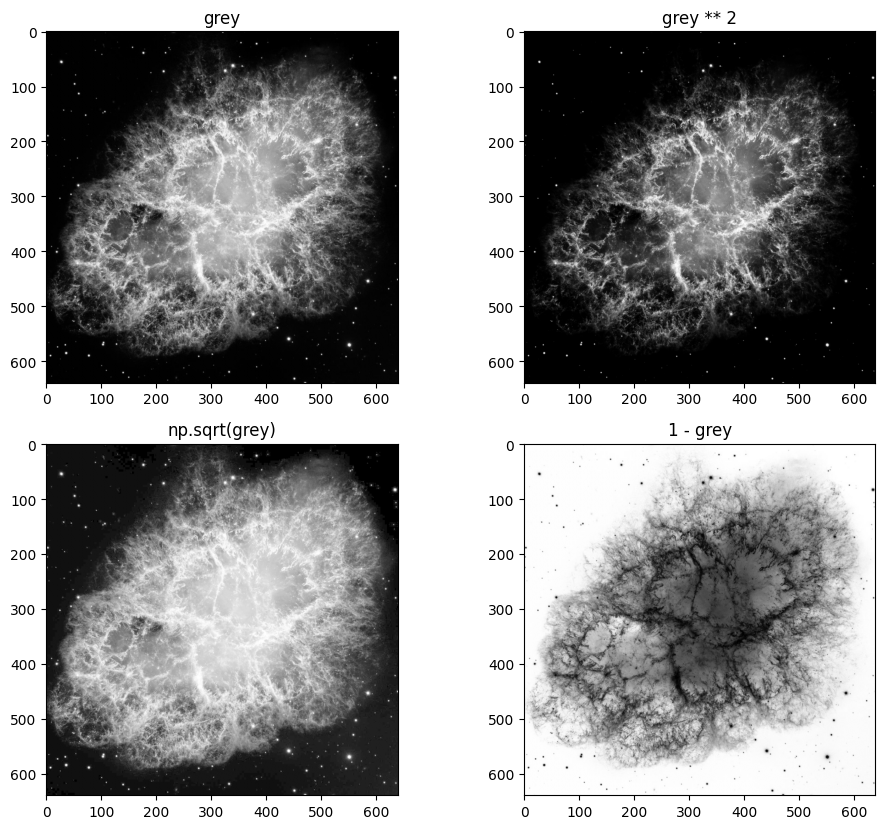

In [9]:
darker = grey ** 2
lighter = np.sqrt(grey)
negative = 1 - grey

print(f"mean brightness: grey {grey.mean():.2f}, grey ** 2 {darker.mean():.2f}, "
      f"np.sqrt(grey) {lighter.mean():.2f}, 1 - grey {negative.mean():.2f}")
show([grey, darker, lighter, negative], ["grey", "grey ** 2", "np.sqrt(grey)", "1 - grey"])

## <font color="#1967d2"><b>Step 15: Your own transformation</b></font>

**Your turn.** Make a new picture from your colour image by computing with its channels. Complete the function `our_transform` in the next code cell, yourselves or with an AI assistant. The function takes the array `image` and returns an array with the same height and width. Values below 0 or above 1 are drawn as 0 or 1.

Some starting points; you are not limited to them:

- exchange two channels, or set one channel to 0;
- apply a pointwise operation of Step 14 to one channel only;
- replace one channel by the grey image.

When the picture is what you want:

1. write in the cell marked **Our prompt** the prompt you used, or that you wrote the function yourselves;
2. **post the two pictures now** on the discussion board of this meeting, as a reply to your group's post of Act 1. One member posts for the group, and it need not be the member who posted in Act 1. Begin the post with the names of all the members of your group. Add one sentence that says what the transformation does;
3. keep the prompt and the function. **Review Quiz 10** asks for them, and asks you to explain what the function does to the array.

**Our prompt.** Double-click this cell and replace this line with your prompt, or with a note that you wrote the function yourselves.

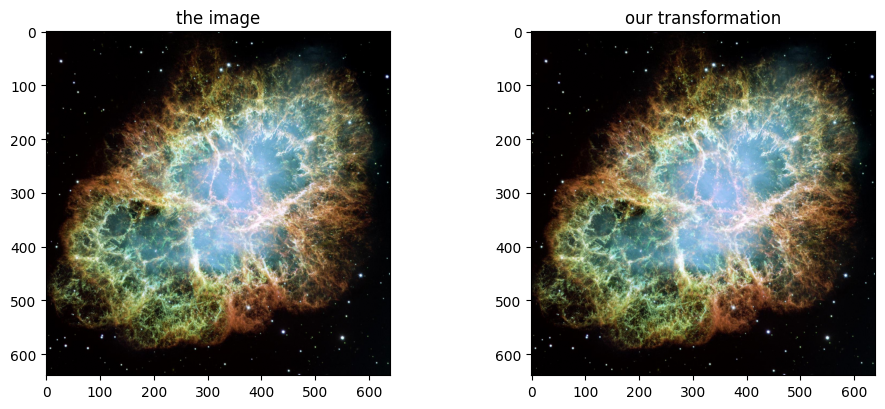

In [10]:
def our_transform(image):
    new = image.copy()               # a copy, so that image stays as it was
    # Your turn: change the array new here.
    return new


new_picture = our_transform(image)
assert new_picture.shape[:2] == (H, W), "The new picture must have the same height and width as the image."
show([image, new_picture], ["the image", "our transformation"])

## <font color="#1967d2"><b>Step 16: One image is one point</b></font>

In Act 1 every row of the matrix `X` was one **point**: one record, with m coordinates. An image is one point too. Its coordinates are all of its numbers, H × W × 3 of them. `image.reshape(-1)` writes the same numbers as a single row.

A point can carry a **label**: a value that says of which kind the point is. Each of the course's thirty images has one: 0 for an artwork, 1 for an image taken in space.

In [11]:
point = image.reshape(-1)             # the same numbers, written as one row
print(f"image has shape {image.shape}. As one point, it has {point.shape[0]:,} coordinates.")
print(f"The label of image {IMAGE} is {picture_info['label']}: {picture_info['kind']}.")

image has shape (640, 640, 3). As one point, it has 1,228,800 coordinates.
The label of image 20 is 1: space image.


**Your turn.** The thirty images of the course are to be stored together in one array, each of them reduced to 96 by 96 pixels. Before you run the next step, answer in the next cell: how many dimensions does that array have, and what does each dimension count?

**Our answer.** Double-click this cell and replace this line with your answer.

## <font color="#1967d2"><b>Step 17: A batch of images</b></font>

Several points that are stored and processed together are called a **batch**. In Act 1 the batch was the whole matrix `X`: n points, in n rows. A batch of colour images is an array with **four** dimensions:

| Data | One point | A batch of n points |
|---|---|---|
| A row of a table (Act 1) | m numbers | n by m |
| A grey image | H by W | n by H by W |
| A colour image | H by W by 3 | n by H by W by 3 |

To be stored in one array, the images of a batch must all have the same size. The next cell reads the thirty images of the course, each cut to a square and reduced to 96 by 96 pixels, with their thirty labels, and draws them.

shape of batch: (30, 96, 96, 3) - image, row, column, channel
shape of batch[0], the first image: (96, 96, 3)
numbers in the batch: 829,440
the thirty labels: [0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1]


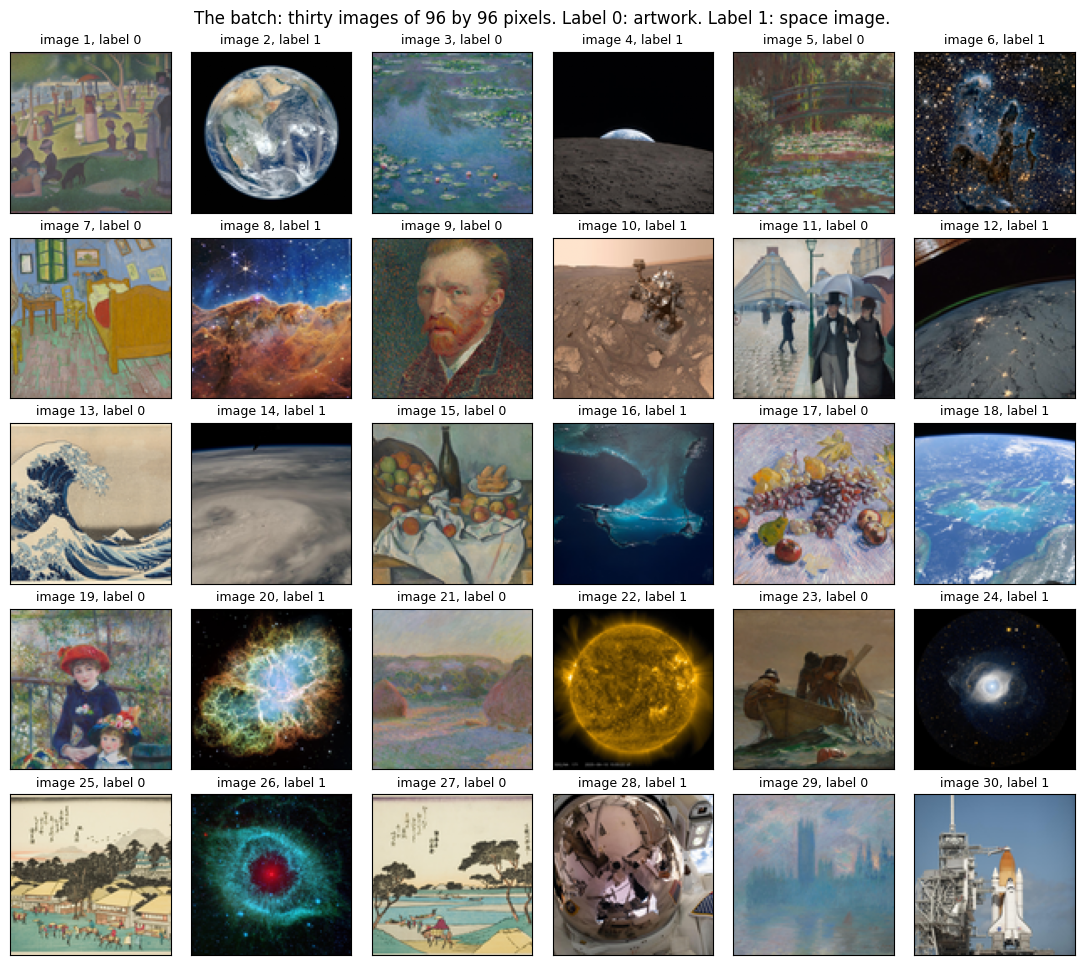

In [12]:
batch = read_array("batch-96.npy")
labels = images["label"].to_numpy()

print("shape of batch:", batch.shape, "- image, row, column, channel")
print("shape of batch[0], the first image:", batch[0].shape)
print(f"numbers in the batch: {batch.size:,}")
print("the thirty labels:", labels)

fig, axes = plt.subplots(5, 6, figsize=(11, 9.8))
for k, ax in enumerate(axes.flat):
    ax.imshow(batch[k])
    ax.set_title(f"image {k + 1}, label {labels[k]}", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("The batch: thirty images of 96 by 96 pixels. Label 0: artwork. Label 1: space image.")
fig.tight_layout()
plt.show()

**One operation for the whole batch.** The line of Step 13 that turned one colour image into a grey image needs only one more colon to convert all thirty images at once. After that, `mean(axis=(1, 2))` averages over the rows and the columns of every image and leaves one number for each image: its mean brightness.

**A batch is also the matrix of Act 1.** `batch.reshape(30, -1)` writes every image as one row: 30 points, with 27,648 coordinates each.

In [13]:
grey_batch = 0.299 * batch[:, :, :, 0] + 0.587 * batch[:, :, :, 1] + 0.114 * batch[:, :, :, 2]
brightness = grey_batch.mean(axis=(1, 2))        # one number for each image
X_images = batch.reshape(30, -1)                 # one row for each image

print("shape of grey_batch:", grey_batch.shape)
print("shape of brightness:", brightness.shape)
print("shape of X_images:  ", X_images.shape)
print()
# brightness[labels == 0] selects the numbers of the images whose label is 0
print(f"mean brightness of the artworks (label 0):     {brightness[labels == 0].mean():.2f}")
print(f"mean brightness of the space images (label 1): {brightness[labels == 1].mean():.2f}")
guess = (brightness < 0.35).astype(int)          # the rule: an image darker than 0.35 is a space image
print(f"The rule 'darker than 0.35 means space image' gives the right label for {(guess == labels).sum()} of the 30 images.")

shape of grey_batch: (30, 96, 96)
shape of brightness: (30,)
shape of X_images:   (30, 27648)

mean brightness of the artworks (label 0):     0.49
mean brightness of the space images (label 1): 0.30
The rule 'darker than 0.35 means space image' gives the right label for 23 of the 30 images.


**How to read the result.** One number computed from each image, its mean brightness, gives the right label for most of the thirty images. A rule of this kind, which computes one number from a point and compares it with a threshold, is what meeting 11 calls a neuron.

## <font color="#1967d2"><b>Step 18: When one operation is not enough</b></font>

Every new picture in this act came from arithmetic on whole arrays, and the loop over the pixels ran inside NumPy.

**Your turn.** Think of a transformation of an image that would be interesting to see and that you **cannot** write as arithmetic on whole arrays. For example, the new value of a pixel may depend on new values that were already computed for other pixels, so that the pixels have to be visited one after another, in order. Describe your transformation in the next cell, in one or two sentences.

Then discuss in your group: when a computation cannot be vectorized, is a slow Python loop the only choice? An assignment of this unit returns to this question.

**Our answer.** Double-click this cell and replace this line with the description of your transformation.

## Act 2 ends here

**Keep your copy of this notebook**, with your group's results in it: Review Quiz 10 asks about them.

Act 3 has its own notebook. It is linked in the module of this meeting on Canvas, and here: [open the notebook of Act 3 in Colab](https://colab.research.google.com/github/ikoutis/cs301-labs/blob/main/unit-2/notebooks/meeting-10-act-3.ipynb).